In [1]:
# command to auto-reload modules when they are edited (easier for testing and debugging)
%load_ext autoreload
%autoreload 2

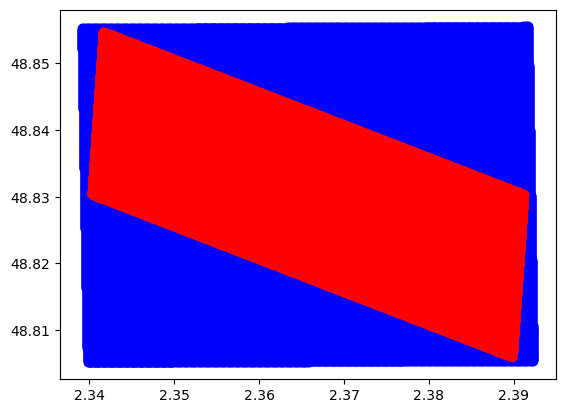

In [2]:
import healpix_geo 
import numpy as np
from foscat.Plot import lgnomproject
import matplotlib.pyplot as plt

level=20
lon=np.load('/home/jmdeloui/healpix-plot/lon.npy')
lat=np.load('/home/jmdeloui/healpix-plot/lat.npy')
out_cell=np.load('/home/jmdeloui/healpix-plot/toto.npy')
val=lon
import healpix_geo.nested as hp

p,t=hp.healpix_to_lonlat(out_cell,20,ellipsoid='WGS84')

plt.scatter(lon,lat,color='b')
plt.scatter(p,t,color='r')

In [3]:
%%time
from healpix_resample import NearestResampler
print(level)
nr = NearestResampler(lon_deg=lon,
                      lat_deg=lat, 
                      level=level,
                      device='cuda:0',
                      out_cell_ids=out_cell,
                      verbose=True,
                      ellipsoid='WGS84'
                     )  # Npt=1 imposé dans nearest
# puis:

20
CPU times: user 4.58 s, sys: 509 ms, total: 5.09 s
Wall time: 3.17 s


In [4]:
res     = nr.resample(val)  # selon ton API
rval     = nr.invert(res.cell_data)
cell_ids = res.cell_ids
res.cell_data.shape,rval.shape,res.cell_data.min()

((262144,), (215388,), np.float64(2.3403054987680347))

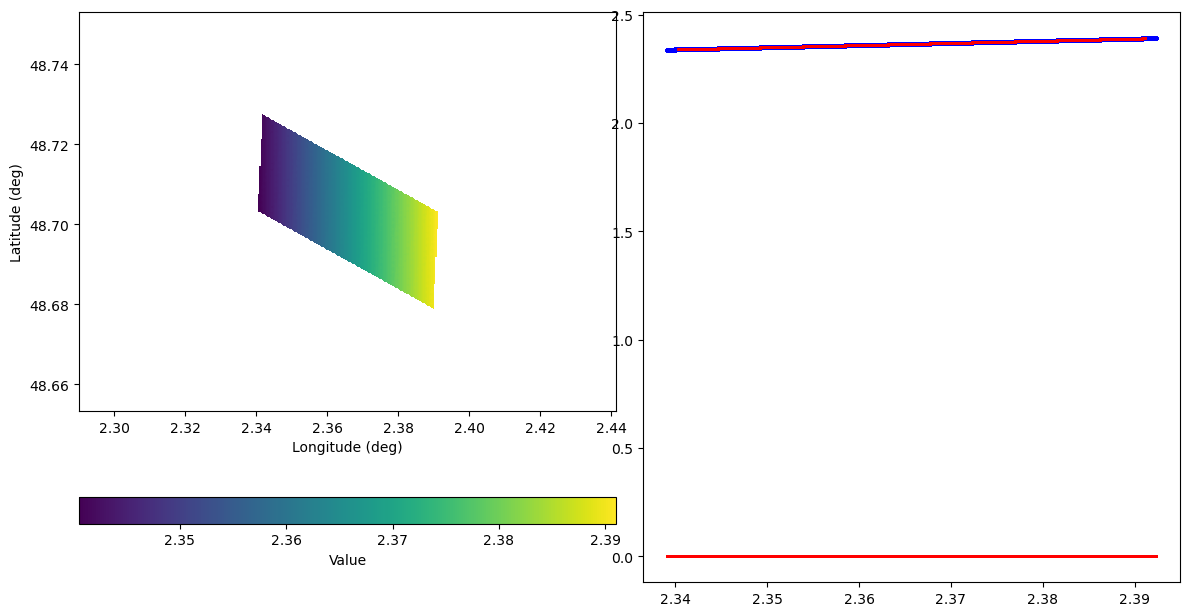

In [5]:
plt.figure(figsize=(12,6))
lgnomproject(res.cell_ids,res.cell_data,2**(20),hold=False,fov_deg=0.1,interp=False,sub=(1,2,1),cbar=True)
plt.subplot(1,2,2)
plt.scatter(lon,lon,color='b',s=4)
plt.scatter(lon,rval,color='r',s=1)
np.mean((rval-lon)**2)
cell_ids_from_bili = cell_ids

In [6]:
import healpix_geo 
import numpy as np
from foscat.Plot import lgnomproject
import matplotlib.pyplot as plt

level=20
ilevel=20
ndata=512
lon,lat=np.meshgrid(0.03*np.arange(ndata)/ndata,0.03*np.arange(ndata)/ndata)
#cell_ids=3*4**ilevel+np.arange(ndata*ndata)
#cell_ids=np.max(cell_ids)+1
lon=lon.T.ravel()
lat=lat.T.ravel()
out_cell = healpix_geo.nested.lonlat_to_healpix(lon,lat, ilevel,ellipsoid='WGS84')
out_cell = np.unique(np.repeat(out_cell//4,4)*4+np.tile(np.arange(4),out_cell.shape[0]))
'''
nline=32
lon=np.concatenate([-0.2*np.arange(nline)/nline,lon])
lat=np.concatenate([0.0*np.arange(nline)/nline,lat])
'''
val=lon
val.shape

(262144,)

In [7]:
from healpix_resample import GroupByResampler

nr = GroupByResampler(lon_deg=lon, lat_deg=lat,reduce="amin",level=19)
# puis:
res     = nr.resample(val)  # selon ton API
rval     = nr.invert(res.cell_data)
cell_ids = res.cell_ids
np.max(rval-val)

np.float64(0.0)

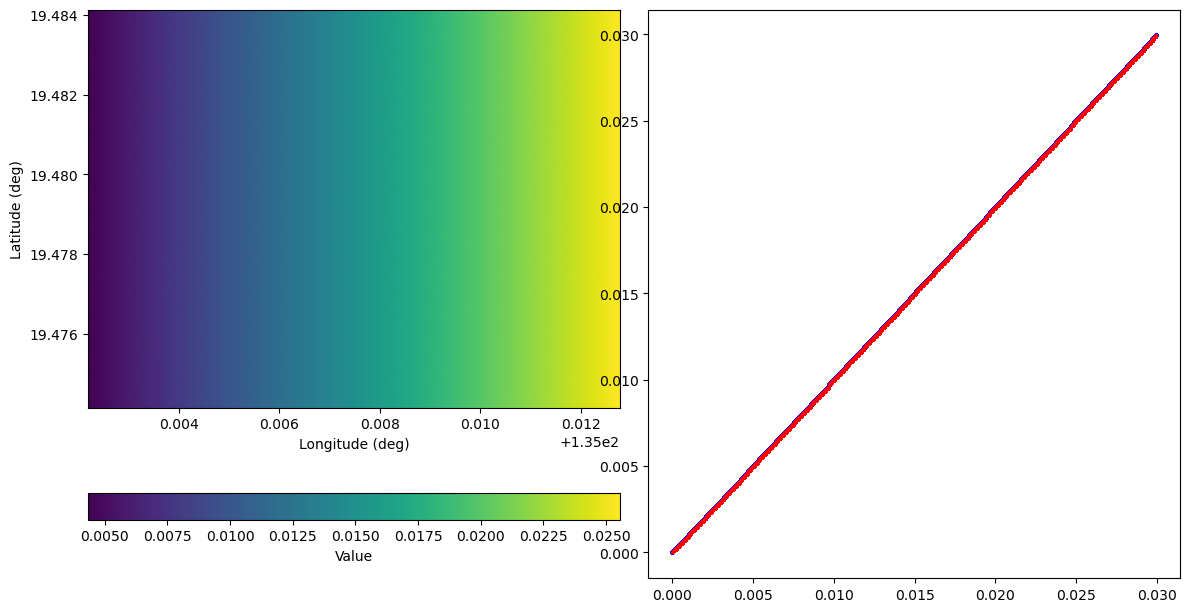

In [8]:
plt.figure(figsize=(12,6))
lgnomproject(res.cell_ids,res.cell_data,2**(20),hold=False,fov_deg=0.01,interp=False,sub=(1,2,1),cbar=True)
plt.subplot(1,2,2)
plt.scatter(lon,lon,color='b',s=4)
plt.scatter(lon,rval,color='r',s=1)
np.mean((rval-lon)**2)
cell_ids_from_bili = cell_ids

In [9]:
from healpix_resample import CellPointResampler

nr = CellPointResampler(lon_deg=lon, lat_deg=lat,reduce="sum")
# puis:
res     = nr.resample(val)  # selon ton API
rval     = nr.invert(res.cell_data)
cell_ids = res.cell_ids
np.max(rval-val)

np.float64(0.0)

In [10]:
import healpix_geo
lo,la=healpix_geo.nested.healpix_to_lonlat(cell_ids, 29,ellipsoid='WGS84')

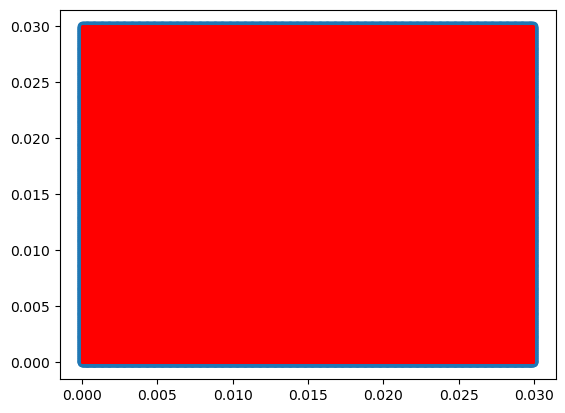

In [11]:
lo[lo>180]-=360
plt.scatter(lon,lat)
plt.scatter(lo,la,color='r',s=1)

np.float64(0.0)

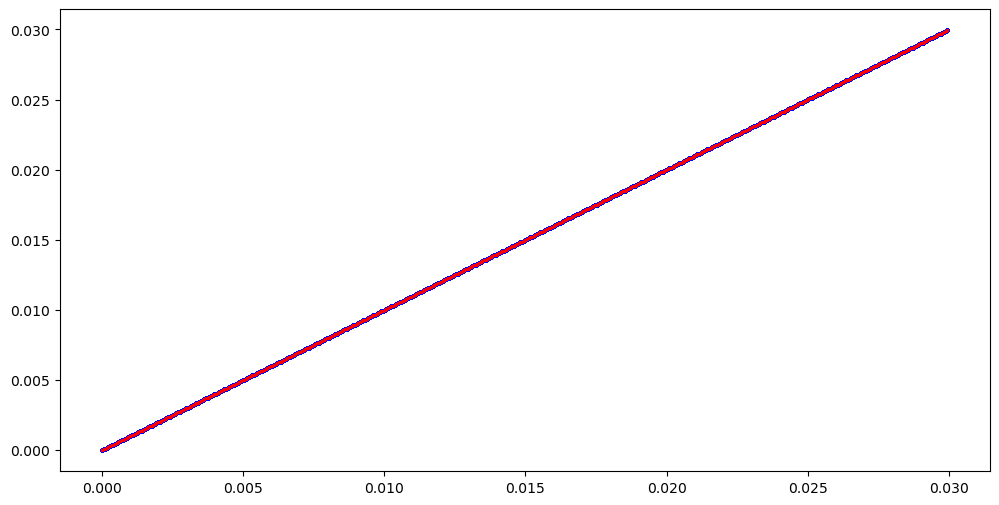

In [12]:
plt.figure(figsize=(12,6))
plt.scatter(lon,lon,color='b',s=4)
plt.scatter(lon,rval,color='r',s=1)
np.mean((rval-lon)**2)

In [13]:
from healpix_resample import BilinearResampler

nr = BilinearResampler(lon_deg=lon, lat_deg=lat, level=level)  # Npt=1 imposé dans nearest
# puis:
res     = nr.resample(val,lam=0.0)  # selon ton API
rval     = nr.invert(res.cell_data)
cell_ids = res.cell_ids
res.cell_data.shape,rval.shape

/home/jmdeloui/healpix-resample/healpix_resample/bilinear.py:74: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:49.)
  self.M  = M_coo.to_sparse_csr()


((287760,), (262144,))

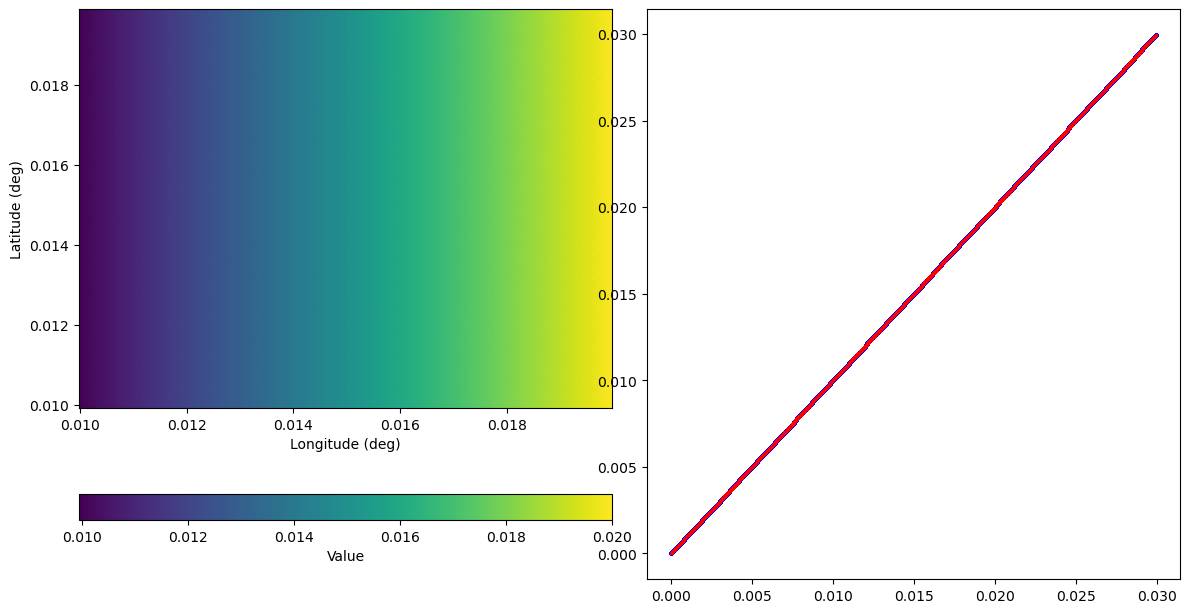

In [14]:
plt.figure(figsize=(12,6))
lgnomproject(res.cell_ids,res.cell_data,2**(level),hold=False,fov_deg=0.01,interp=False,sub=(1,2,1),cbar=True)
plt.subplot(1,2,2)
plt.scatter(lon,lon,color='b',s=4)
plt.scatter(lon,rval,color='r',s=1)
np.mean((rval-lon)**2)
cell_ids_from_bili = cell_ids

In [15]:
from healpix_resample import PSFResampler

nr = PSFResampler(lon_deg=lon, lat_deg=lat, level=level,threshold=0.5,verbose=True)  # Npt=1 imposé dans nearest
# puis:
res     = nr.resample(val,lam=0.0)  # selon ton API
rval     = nr.invert(res.cell_data)
cell_ids = res.cell_ids
res.cell_data.shape,rval.shape

Itt 0 : 6.497e-08
Itt 4 : 7.545e-11
Itt 8 : 1.949e-12
Itt 12 : 1.264e-12
Itt 16 : 1.705e-13
Itt 20 : 8.165e-15
Itt 24 : 1.351e-13
Itt 28 : 5.612e-12
Itt 32 : 1.605e-10
Itt 36 : 1.104e-11
Itt 40 : 2.368e-12
Itt 44 : 2.513e-12
Itt 48 : 2.426e-13
Itt 52 : 1.497e-14
Itt 56 : 1.749e-13
Itt 60 : 2.893e-12
Itt 64 : 1.599e-11
Itt 68 : 9.162e-12
Itt 72 : 4.39e-11
Itt 76 : 1.33e-11
Itt 80 : 8.306e-13
Itt 84 : 2.111e-13
Itt 88 : 1.869e-13
Itt 92 : 1.762e-14
Itt 96 : 1.244e-14
Final Itt 99 : 4.093e-14


((286938,), (262144,))

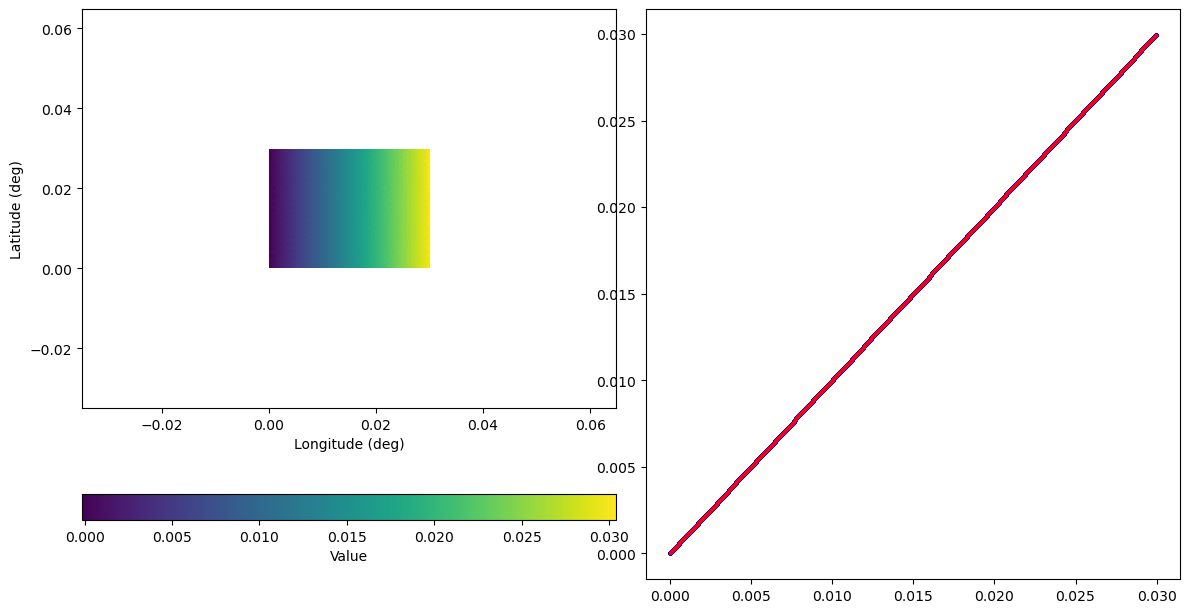

In [16]:
plt.figure(figsize=(12,6))
lgnomproject(res.cell_ids,res.cell_data,2**(level),hold=False,fov_deg=0.1,interp=False,sub=(1,2,1),cbar=True)
plt.subplot(1,2,2)
plt.scatter(lon,lon,color='b',s=4)
plt.scatter(lon,rval,color='r',s=1)
np.mean((rval-lon)**2)
out_cell=res.cell_ids

np.float64(8.667946950614571e-15)

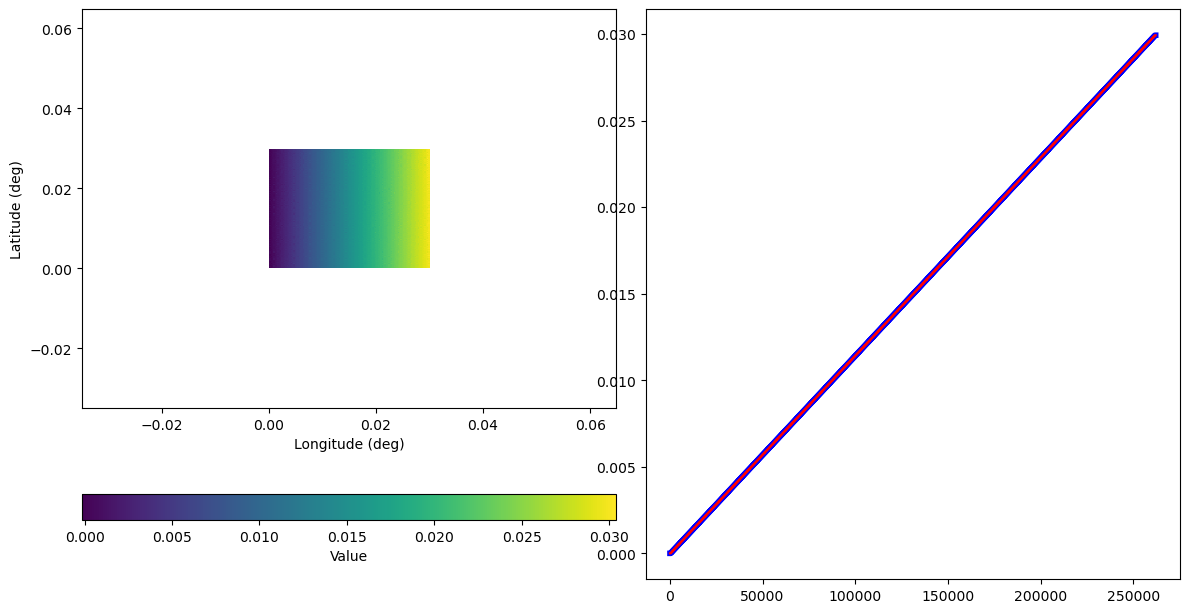

In [17]:

plt.figure(figsize=(12,6))
lgnomproject(res.cell_ids,res.cell_data,2**(level),hold=False,fov_deg=0.1,interp=False,sub=(1,2,1),cbar=True)
plt.subplot(1,2,2)
plt.plot(lon,color='b',lw=4)
plt.plot(rval,color='r')
np.mean((rval-lon)**2)

<Axes: xlabel='Longitude (deg)', ylabel='Latitude (deg)'>

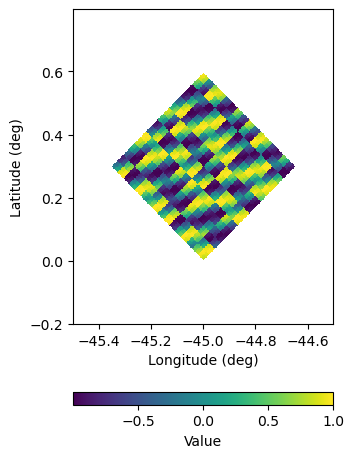

In [18]:
ilevel=14
ndata=128
cell_ids=3*4**ilevel+np.arange(ndata*ndata)
val=np.cos(cell_ids/100.) # fake data
lgnomproject(cell_ids,val,2**(ilevel),hold=False,fov_deg=1,interp=False,sub=(1,2,1),cbar=True)

In [19]:
import xarray as xr
zarr_file_path = 'https://data-fair2adapt.ifremer.fr/riomar-zarr_tina/small.zarr'
small_ds=xr.open_zarr(zarr_file_path)
small_ds
ds=small_ds.temp.isel(s_rho=0,time_counter=0).compute()
ds = ds.stack(point=("y_rho","x_rho")).dropna(dim="point")
ds

<xarray.DataArray 'temp' (point: 2699)> Size: 11kB
array([15.223061, 15.067629, 15.098939, ..., 12.425324, 12.690933,
       12.314169], shape=(2699,), dtype=float32)
Coordinates:
  * point         (point) object 22kB MultiIndex
    mask          (point) bool 3kB True True True True ... True True True True
    nav_lat_rho   (point) float32 11kB 46.9 46.91 46.91 ... 47.42 47.43 47.43
    nav_lon_rho   (point) float32 11kB -2.773 -2.867 -2.853 ... -2.613 -2.52
    s_rho         float32 4B -0.9875
    time_counter  datetime64[ns] 8B 2023-12-01T00:48:10
    time_instant  datetime64[ns] 8B NaT
  * y_rho         (point) float32 11kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
  * x_rho         (point) float32 11kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes:
    long_name:           potential temperature
    units:               Celsius
    online_operation:    instant
    interval_operation:  1 h
    interval_write:      1 h
    cell_methods:        time: point

In [20]:
child_level=13

# Build operator once
lon = ds["nav_lon_rho"].values.astype(np.float64)
lat = ds["nav_lat_rho"].values.astype(np.float64)

nr_bili = BilinearResampler(lon_deg=lon, lat_deg=lat, level=child_level, device="cuda", threshold=0.5, ellipsoid="WGS84")
nr_psf = PSFResampler(lon_deg=lon, lat_deg=lat, level=child_level, device="cuda", threshold=0.5, ellipsoid="WGS84",out_cell_ids=nr_bili.get_cell_ids(),verbose=True)

cell_ids=nr_psf.get_cell_ids()
ncell = int(cell_ids.size)

data1d = np.asarray(ds.compute(), dtype=np.float64)

def to_healpix_point(data_1d,nr):
    out = nr.resample(data_1d, lam=0.1)#.1)
    return np.asarray(out.cell_data, dtype=np.float64)
    
ar1=to_healpix_point(data1d,nr_psf)
ar2=to_healpix_point(data1d,nr_bili)

/home/jmdeloui/healpix-resample/healpix_resample/psf.py:268: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  add_cols.append(torch.tensor(bad_k[kb:kb+1], dtype=torch.long))
/home/jmdeloui/healpix-resample/healpix_resample/psf.py:339: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  add_cols.append(torch.tensor(bad_k[kb:kb+1], dtype=torch.long))


Itt 0 : 0.1296
Itt 4 : 3.292e-05
Itt 8 : 2.354e-08
Itt 12 : 2.24e-11
Itt 16 : 1.767e-14
Final Itt 19 : 8.93e-17


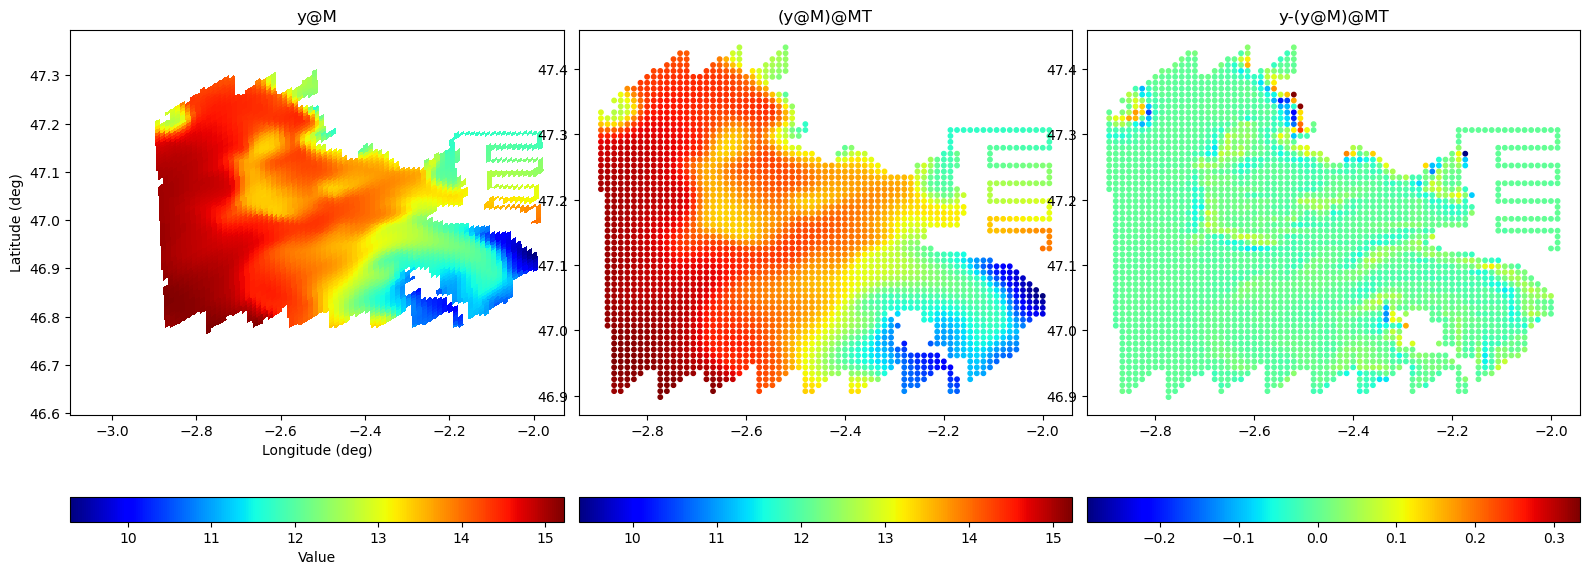

In [21]:
#v=nr_psf.M.to_dense().cpu().numpy()
import torch

r=(torch.tensor(data1d,device='cuda',dtype=torch.float)@nr_psf.M).cpu().numpy()
rinv=(torch.tensor(r,device='cuda',dtype=torch.float)@nr_psf.MT).cpu().numpy()
plt.figure(figsize=(16,6))
lgnomproject(cell_ids,r,2**(child_level),fov_deg=0.8,interp=False,cbar=True,hold=False,sub=(1,3,1),cmap='jet',title='y@M')
plt.subplot(1,3,2)
plt.title('(y@M)@MT')
plt.scatter(lon,lat,c=rinv,s=10,cmap='jet')
plt.colorbar(location='bottom')
plt.subplot(1,3,3)
plt.title('y-(y@M)@MT')
plt.scatter(lon,lat,c=rinv-data1d,s=10,cmap='jet')
plt.colorbar(location='bottom')

<Axes: title={'center': 'Bilinear-PSF'}, xlabel='Longitude (deg)', ylabel='Latitude (deg)'>

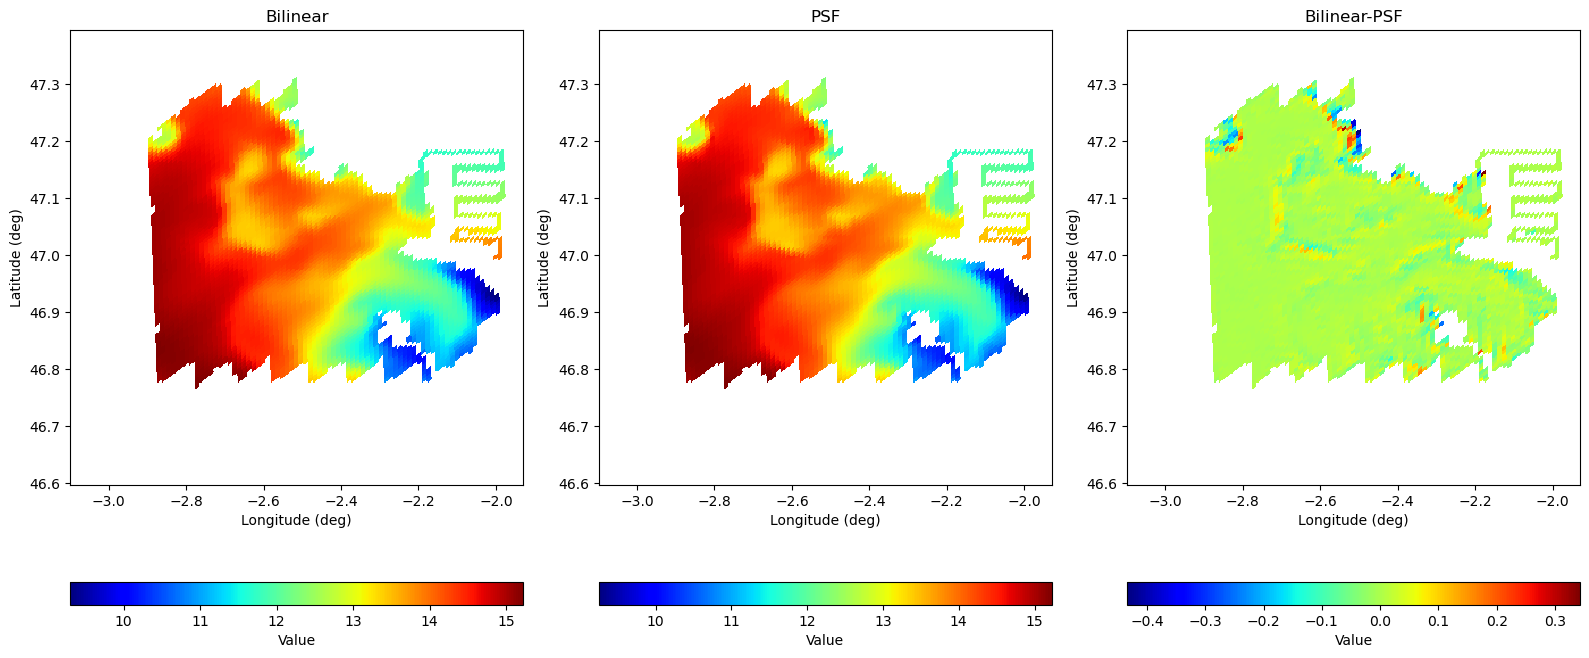

In [22]:
plt.figure(figsize=(16,7))
lgnomproject(cell_ids,(ar2),2**(child_level),hold=False,sub=(1,3,1),fov_deg=0.8,interp=False,cbar=True,cmap='jet',title='Bilinear')
lgnomproject(cell_ids,(ar1),2**(child_level),hold=False,sub=(1,3,2),fov_deg=0.8,interp=False,cbar=True,cmap='jet',title='PSF')
lgnomproject(cell_ids,(ar1-ar2),2**(child_level),hold=False,sub=(1,3,3),fov_deg=0.8,interp=False,cbar=True,cmap='jet',title='Bilinear-PSF')

In [23]:
rval1     = nr_psf.invert(ar1)
rval2     = nr_bili.invert(ar2)

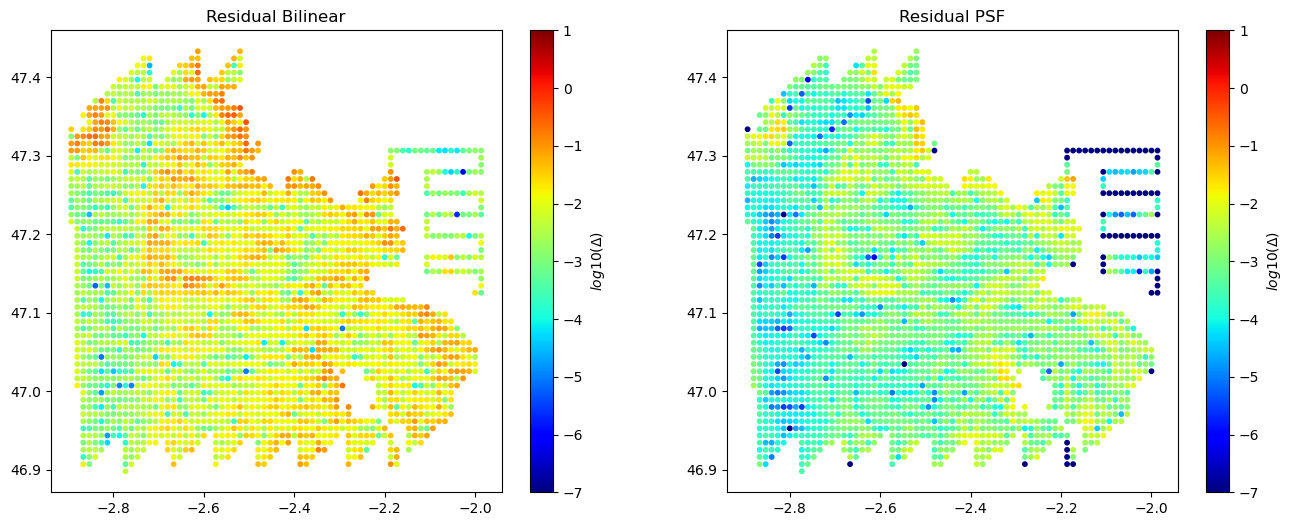

In [24]:
plt.figure(figsize=(16,6))
plt.subplot(1,2,2)
plt.title('Residual PSF')
plt.scatter(lon,lat,c=np.log10(abs(ds.compute()-rval1)+1e-7),s=10,vmin=-7,vmax=1,cmap='jet')
plt.colorbar(label=r'$log10(\Delta)$')
plt.subplot(1,2,1)
plt.title('Residual Bilinear')
plt.scatter(lon,lat,c=np.log10(abs(ds.compute()-rval2)),s=10,vmin=-7,vmax=1,cmap='jet')
plt.colorbar(label=r'$log10(\Delta)$')